# 06 — Final Test Evaluation

**Insurance Claim Fraud Detection & Action Recommendation System**

This is the final, one-shot evaluation on the locked test set, plus a
temporal robustness check. Everything used here — model, calibration,
threshold, risk tiers — was already frozen in Notebooks 04-05. **This
notebook measures. It does not choose, tune, or fit anything on the test
set.**

**The rule that makes this notebook meaningful:** the test set is opened
exactly once, in this notebook, and nowhere else in the project. If a result
below looks disappointing, it is reported as-is, not adjusted — going back
to nudge a threshold, re-calibrate, or re-select a model *because of* a test
number would retroactively turn the test set into just another tuning set,
and every number in this project (including the ones that already looked
fine) would become suspect. That discipline is worth restating at the one
moment it's hardest to keep: Step 1, right after the confusion matrix.

**What this notebook does:**
1. Loads the frozen model, calibration, threshold, and tier config — fits
   nothing
2. Scores the test set once: full metric set, confusion matrix at the frozen
   threshold, tier table, reliability curve
3. Compares validation vs. test honestly — the test number is the headline
   real-world estimate
4. Retrains the same modelling *recipe* from scratch on 1994-95 data only,
   evaluated once on 1996 — a separate, throwaway robustness check, not a
   second candidate model

**Explicitly out of scope here:** changing the threshold, re-calibrating,
re-selecting the model, tuning anything, or letting any number from this
notebook feed back into an earlier decision.

## 1. Environment & Google Drive Setup

Same conventions as Notebooks 01-05: everything derives from one
`PROJECT_ROOT`, Drive is mounted first, and every expected input is verified
to exist before this notebook does any work.

In [1]:
"""Notebook 06 - Final Test Evaluation: imports and shared configuration."""
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, matthews_corrcoef, precision_recall_curve, precision_score, recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

TARGET_COL = "FraudFound_P"
RANDOM_STATE = 42

# Same fixed categorical palette as Notebooks 01/03/04/05, kept self-contained here.
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}

saved_files = []  # every artifact written to Drive is recorded here for the final recap
print("Libraries imported.")

Libraries imported.


### Mount Google Drive

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook is designed to run in Google Colab with the team's shared "
        "Drive mounted. `google.colab` is not available in this environment - open "
        "the notebook in Colab and re-run."
    ) from exc

Mounted at /content/drive


### Define project paths

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/InsuranceFraudProject")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_TEST_DIR = RESULTS_DIR / "figures" / "test"
MODELS_DIR = PROJECT_ROOT / "models"

TEST_PATH = DATA_PROCESSED_DIR / "test.parquet"
TRAIN_TEMPORAL_PATH = DATA_PROCESSED_DIR / "train_temporal.parquet"
TEST_TEMPORAL_PATH = DATA_PROCESSED_DIR / "test_temporal.parquet"
PIPELINE_PATH = MODELS_DIR / "preprocessing_pipeline.joblib"
CALIBRATED_MODEL_PATH = MODELS_DIR / "calibrated_model.joblib"
RISK_CONFIG_PATH = MODELS_DIR / "risk_config.json"
BEST_MODEL_CONFIG_PATH = MODELS_DIR / "best_model_config.json"
EXPERIMENTS_CSV_PATH = RESULTS_DIR / "experiments.csv"
METRICS_JSON_PATH = RESULTS_DIR / "metrics.json"

FIGURES_TEST_DIR.mkdir(parents=True, exist_ok=True)

print("Project configuration")
print("-" * 60)
print(f"PROJECT_ROOT              : {PROJECT_ROOT}")
print(f"TEST_PATH                  : {TEST_PATH}")
print(f"TRAIN_TEMPORAL_PATH        : {TRAIN_TEMPORAL_PATH}")
print(f"TEST_TEMPORAL_PATH         : {TEST_TEMPORAL_PATH}")
print(f"PIPELINE_PATH              : {PIPELINE_PATH}")
print(f"CALIBRATED_MODEL_PATH      : {CALIBRATED_MODEL_PATH}")
print(f"RISK_CONFIG_PATH           : {RISK_CONFIG_PATH}")
print(f"BEST_MODEL_CONFIG_PATH     : {BEST_MODEL_CONFIG_PATH}")
print(f"EXPERIMENTS_CSV_PATH       : {EXPERIMENTS_CSV_PATH}")
print(f"METRICS_JSON_PATH          : {METRICS_JSON_PATH}")

Project configuration
------------------------------------------------------------
PROJECT_ROOT              : /content/drive/MyDrive/InsuranceFraudProject
TEST_PATH                  : /content/drive/MyDrive/InsuranceFraudProject/data/processed/test.parquet
TRAIN_TEMPORAL_PATH        : /content/drive/MyDrive/InsuranceFraudProject/data/processed/train_temporal.parquet
TEST_TEMPORAL_PATH         : /content/drive/MyDrive/InsuranceFraudProject/data/processed/test_temporal.parquet
PIPELINE_PATH              : /content/drive/MyDrive/InsuranceFraudProject/models/preprocessing_pipeline.joblib
CALIBRATED_MODEL_PATH      : /content/drive/MyDrive/InsuranceFraudProject/models/calibrated_model.joblib
RISK_CONFIG_PATH           : /content/drive/MyDrive/InsuranceFraudProject/models/risk_config.json
BEST_MODEL_CONFIG_PATH     : /content/drive/MyDrive/InsuranceFraudProject/models/best_model_config.json
EXPERIMENTS_CSV_PATH       : /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv
MET

### Verify expected inputs exist

Eight inputs are required. `test.parquet` is opened **exactly once**, later
in this notebook, and nowhere else in the project.

In [4]:
missing_inputs = []
for label, path in [
    ("test.parquet", TEST_PATH), ("train_temporal.parquet", TRAIN_TEMPORAL_PATH),
    ("test_temporal.parquet", TEST_TEMPORAL_PATH), ("preprocessing_pipeline.joblib", PIPELINE_PATH),
    ("calibrated_model.joblib", CALIBRATED_MODEL_PATH), ("risk_config.json", RISK_CONFIG_PATH),
    ("best_model_config.json", BEST_MODEL_CONFIG_PATH), ("experiments.csv", EXPERIMENTS_CSV_PATH),
]:
    if not path.exists():
        missing_inputs.append((label, path))

if missing_inputs:
    details = "\n".join(f"  - {label}: {path}" for label, path in missing_inputs)
    raise FileNotFoundError(
        f"Missing required input(s):\n{details}\n\n"
        "Run Notebooks 02 through 05 first - this notebook loads their saved outputs "
        "rather than recreating them."
    )

print("Found all required inputs.")

Found all required inputs.


## 2. Load the Frozen Artifacts

Loaded, not recreated, and nothing here is refit. `risk_config.json` carries
the operating threshold and tier boundaries chosen on validation in Notebook
05 - they are used **verbatim** below; this notebook contains no
threshold-selection or tier-boundary code of its own.

In [5]:
with open(RISK_CONFIG_PATH, "r", encoding="utf-8") as f:
    risk_config = json.load(f)

with open(BEST_MODEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    best_model_config = json.load(f)

preprocessing_pipeline = joblib.load(PIPELINE_PATH)

operating_threshold = risk_config["operating_threshold"]
LOW_RISK_MAX = risk_config["risk_tiers"]["low_max"]
HIGH_RISK_MIN = risk_config["risk_tiers"]["high_min"]

print(f"Calibration method:  {risk_config['calibration_method']}")
print(f"Operating threshold: {operating_threshold}  (loaded from risk_config.json - not recomputed)")
print(f"Risk tiers:           Low < {LOW_RISK_MAX}  |  Medium < {HIGH_RISK_MIN}  |  High >= {HIGH_RISK_MIN}")
print(f"Source model:         {best_model_config['model_name']} + {best_model_config['balancing_strategy']} "
      f"(Optuna trial #{best_model_config['optuna']['trial_number']})")

Calibration method:  isotonic
Operating threshold: 0.15  (loaded from risk_config.json - not recomputed)
Risk tiers:           Low < 0.075  |  Medium < 0.15  |  High >= 0.15
Source model:         XGBoost + class_weight (Optuna trial #58)


### Reconstruct the classes needed to unpickle the calibrated model

`calibrated_model.joblib` wraps a fitted `EarlyStoppingGBDT` (directly, or via
`CalibratedClassifierCV`/`FrozenEstimator`). Unpickling a custom class
requires it to be defined, under the same name, wherever `joblib.load` runs
— reproduced here **unchanged from Notebooks 04-05**, purely so the saved
model can be loaded. Nothing here re-fits it; it is also reused below,
unchanged, to build a *fresh* model for the Step 3 temporal check, which
trains its own instance from scratch on different data.

In [7]:
class EarlyStoppingGBDT(ClassifierMixin, BaseEstimator):
    """Wraps an XGBoost/LightGBM classifier so a plain .fit(X, y) call automatically
    carves out an internal validation slice and applies early stopping.

    Reproduced unchanged from Notebooks 04-05 (note: ClassifierMixin listed before
    BaseEstimator - required for scikit-learn's newer tag system to correctly detect
    this as a classifier, e.g. inside CalibratedClassifierCV/FrozenEstimator).
    """

    def __init__(self, base_estimator, early_stopping_rounds: int = 50,
                 val_fraction: float = 0.15, random_state: int = RANDOM_STATE):
        self.base_estimator = base_estimator
        self.early_stopping_rounds = early_stopping_rounds
        self.val_fraction = val_fraction
        self.random_state = random_state

    def fit(self, X, y):
        X_fit, X_inner_val, y_fit, y_inner_val = train_test_split(
            X, y, test_size=self.val_fraction, stratify=y, random_state=self.random_state,
        )
        self.estimator_ = clone(self.base_estimator)
        if isinstance(self.estimator_, XGBClassifier):
            self.estimator_.set_params(early_stopping_rounds=self.early_stopping_rounds)
            self.estimator_.fit(X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)], verbose=False)
        elif isinstance(self.estimator_, LGBMClassifier):
            self.estimator_.fit(
                X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)],
                callbacks=[lgb.early_stopping(stopping_rounds=self.early_stopping_rounds, verbose=False)],
            )
        else:
            raise TypeError(f"EarlyStoppingGBDT doesn't know how to early-stop {type(self.estimator_).__name__}")
        self.classes_ = self.estimator_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict_proba(X)


calibrated_model = joblib.load(CALIBRATED_MODEL_PATH)
print(f"Loaded calibrated model: {type(calibrated_model).__name__}")

Loaded calibrated model: CalibratedClassifierCV


## 3. Evaluation Harness (Reused from Notebooks 03/04/05)

Identical function body to earlier notebooks, so every number in this
project - baseline, candidate, validation, and now test - is computed by the
exact same logic.

In [8]:
def compute_fraud_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> dict:
    """Metrics for the fraud (positive) class - reused unchanged from Notebooks 03-05."""
    return {
        "pr_auc": average_precision_score(y_true, y_proba),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
    }


def fit_and_evaluate(model, X_train_: np.ndarray, y_train_: np.ndarray,
                      X_eval: np.ndarray, y_eval: np.ndarray) -> dict:
    """Fit a fresh clone of `model` on X_train_/y_train_, evaluate on X_eval/y_eval.
    Reused unchanged from Notebooks 03-04; used below only for the Step 3 temporal
    model, which is trained from scratch on its own (non-test) data."""
    fitted = clone(model)
    fitted.fit(X_train_, y_train_)
    y_pred = fitted.predict(X_eval)
    y_proba = fitted.predict_proba(X_eval)[:, 1]
    return {
        "model": fitted, "y_pred": y_pred, "y_proba": y_proba,
        "metrics": compute_fraud_metrics(y_eval, y_pred, y_proba),
    }


def log_experiment(row: dict, path: Path) -> None:
    """Append one row to the shared experiments.csv - reused unchanged from Notebooks 03-04."""
    new_row_df = pd.DataFrame([row])
    combined = pd.concat([pd.read_csv(path), new_row_df], ignore_index=True) if path.exists() else new_row_df
    combined.to_csv(path, index=False)
    print(f"Logged '{row['model']}' ({row['eval_split']}) -> {path}")


def to_jsonable(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value


def save_figure(fig, filename: str, note: str = "") -> Path:
    """Save a figure to the test figures directory, record it, and print the path."""
    out_path = FIGURES_TEST_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    saved_files.append(out_path)
    print(f"Saved figure -> {out_path}" + (f"  ({note})" if note else ""))
    return out_path


print("Evaluation harness ready: compute_fraud_metrics, fit_and_evaluate, log_experiment, "
      "to_jsonable, save_figure.")

Evaluation harness ready: compute_fraud_metrics, fit_and_evaluate, log_experiment, to_jsonable, save_figure.


## 4. Step 1 — Final Test-Set Evaluation

**This is the only place in the project that opens `test.parquet`, and it
happens exactly once, right here.** The frozen preprocessing pipeline is
applied with `.transform()` only. Threshold-dependent metrics below
(recall, precision, Macro-F1, MCC, and the confusion matrix) use the
**frozen operating threshold from `risk_config.json`**, not the default 0.5
— 0.5 is not a meaningful cutoff for probabilities calibrated to ~6%
prevalence (Notebook 05 found the calibrated model rarely produces
probabilities anywhere near 0.5). PR-AUC, ROC-AUC, and Brier score are
threshold-independent and unaffected by this choice.

In [9]:
test_df = pd.read_parquet(TEST_PATH)
X_test_df = test_df.drop(columns=[TARGET_COL])
X_test = preprocessing_pipeline.transform(X_test_df)
y_test = test_df[TARGET_COL].to_numpy()

y_proba_test = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= operating_threshold).astype(int)

print(f"test_df: {test_df.shape[0]:,} rows  |  fraud rate: {y_test.mean() * 100:.2f}%")
print(f"X_test: {X_test.shape}")

test_df: 2,313 rows  |  fraud rate: 5.97%
X_test: (2313, 93)


### Full metric set + no-skill reference

In [10]:
test_metrics = compute_fraud_metrics(y_test, y_pred_test, y_proba_test)
no_skill_pr_auc_test = float(y_test.mean())

metrics_table = pd.DataFrame([
    {"metric": k, "value": round(v, 4)} for k, v in test_metrics.items()
])
display(metrics_table)
print(f"\nNo-skill PR-AUC (test fraud prevalence): {no_skill_pr_auc_test:.4f}")
print(f"Test PR-AUC clears no-skill by {test_metrics['pr_auc'] - no_skill_pr_auc_test:.4f}.")

,metric,value
0,pr_auc,0.1945
1,recall,0.2899
2,precision,0.2273
3,macro_f1,0.6003
4,mcc,0.2031
5,roc_auc,0.8297
6,brier_score,0.0515



No-skill PR-AUC (test fraud prevalence): 0.0597
Test PR-AUC clears no-skill by 0.1348.


### Frozen threshold: confusion matrix and operating-point stats

The threshold used below is the one loaded from `risk_config.json` and
printed in Section 2 above — not searched, not adjusted, not re-derived from
test data.

In [11]:
def compute_operating_point(y_true: np.ndarray, y_proba: np.ndarray, threshold: float) -> dict:
    """Recall/precision/FPR/caseload at a single, already-chosen threshold - no search,
    no optimization. Reused logic shape from Notebook 05's sweep, evaluated at one point."""
    y_pred = (y_proba >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    return {
        "threshold": threshold,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "caseload_pct": 100 * (tp + fp) / len(y_true),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


test_operating_point = compute_operating_point(y_test, y_proba_test, operating_threshold)
print(f"At threshold {operating_threshold}:")
print(f"  Recall:    {test_operating_point['recall']:.3f}")
print(f"  Precision: {test_operating_point['precision']:.3f}")
print(f"  FPR:       {test_operating_point['fpr']:.3f}")
print(f"  Caseload:  {test_operating_point['caseload_pct']:.1f}% of test claims flagged")

At threshold 0.15:
  Recall:    0.290
  Precision: 0.227
  FPR:       0.063
  Caseload:  7.6% of test claims flagged


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/confusion_matrix_test.png  (threshold=0.15)


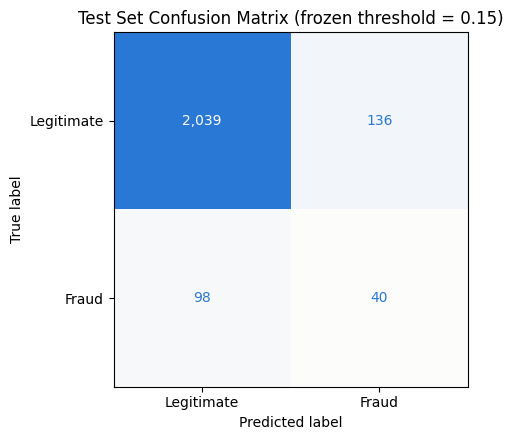

In [12]:
blue_sequential = LinearSegmentedColormap.from_list("blue_sequential", ["#fcfcfb", PALETTE["blue"]])

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=ax, cmap=blue_sequential, colorbar=False, values_format=",")
ax.set_title(f"Test Set Confusion Matrix (frozen threshold = {operating_threshold})")
fig.tight_layout()
save_figure(fig, "confusion_matrix_test.png", note=f"threshold={operating_threshold}")
plt.show()

> **If this confusion matrix looks disappointing: that is the result.** The
> discipline this notebook exists to enforce is exactly here — the correct
> response is to report it honestly in Step 2, not to scroll back up and try
> a different threshold. Any number produced by adjusting the threshold
> *after* seeing this matrix would no longer be a test-set evaluation of the
> frozen configuration; it would be tuning on the test set, and it would
> invalidate every other number in this notebook along with it.

### Frozen risk tiers on the test set

Boundaries loaded from `risk_config.json` — the real-world counterpart to
Notebook 05's validation tier table.

In [13]:
def assign_risk_tier(proba: np.ndarray, low_max: float, high_min: float) -> np.ndarray:
    return np.where(proba >= high_min, "High", np.where(proba >= low_max, "Medium", "Low"))


def summarize_risk_tiers(tiers: np.ndarray, y_true: np.ndarray) -> pd.DataFrame:
    total_fraud = int(y_true.sum())
    rows = []
    for tier in ["Low", "Medium", "High"]:
        mask = tiers == tier
        n_claims = int(mask.sum())
        n_fraud = int(y_true[mask].sum())
        rows.append({
            "tier": tier, "n_claims": n_claims,
            "caseload_pct": round(100 * n_claims / len(y_true), 2),
            "n_fraud": n_fraud,
            "fraud_rate_pct": round(100 * n_fraud / n_claims, 2) if n_claims > 0 else 0.0,
            "recall_share_pct": round(100 * n_fraud / total_fraud, 2) if total_fraud > 0 else 0.0,
        })
    return pd.DataFrame(rows)


test_risk_tier = assign_risk_tier(y_proba_test, LOW_RISK_MAX, HIGH_RISK_MIN)
test_tier_summary_df = summarize_risk_tiers(test_risk_tier, y_test)
display(test_tier_summary_df)

assert int(test_tier_summary_df["n_claims"].sum()) == len(y_test), "Tiers do not partition all test claims."
print("\nPASSED: tiers partition every test claim exactly once.")

,tier,n_claims,caseload_pct,n_fraud,fraud_rate_pct,recall_share_pct
0,Low,1573,68.01,28,1.78,20.29
1,Medium,564,24.38,70,12.41,50.72
2,High,176,7.61,40,22.73,28.99



PASSED: tiers partition every test claim exactly once.


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/risk_tiers_test.png


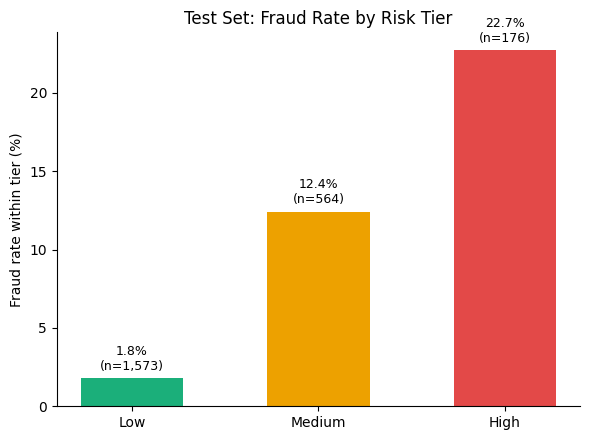

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.5))
tier_colors = [PALETTE["aqua"], PALETTE["yellow"], PALETTE["red"]]
bars = ax.bar(test_tier_summary_df["tier"], test_tier_summary_df["fraud_rate_pct"], color=tier_colors, width=0.55)
for bar, row in zip(bars, test_tier_summary_df.itertuples()):
    ax.annotate(f"{row.fraud_rate_pct:.1f}%\n(n={row.n_claims:,})",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Fraud rate within tier (%)")
ax.set_title("Test Set: Fraud Rate by Risk Tier")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_figure(fig, "risk_tiers_test.png")
plt.show()

### Calibration on test: reliability curve

Confirms the calibration mapping learned on validation still tracks the
diagonal on genuinely unseen data - the real test of whether calibration
generalized, not just fit validation well.

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/reliability_curve_test.png


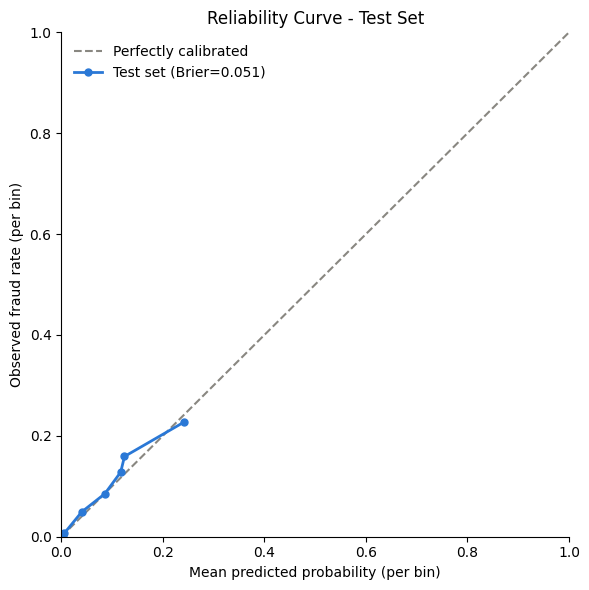

In [15]:
prob_true_test, prob_pred_test = calibration_curve(y_test, y_proba_test, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color="#898781", linestyle="--", linewidth=1.5, label="Perfectly calibrated")
ax.plot(prob_pred_test, prob_true_test, marker="o", markersize=5, color=PALETTE["blue"],
        linewidth=2, label=f"Test set (Brier={test_metrics['brier_score']:.3f})")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed fraud rate (per bin)")
ax.set_title("Reliability Curve - Test Set")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_figure(fig, "reliability_curve_test.png")
plt.show()

### PR curve

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/pr_curve_test.png


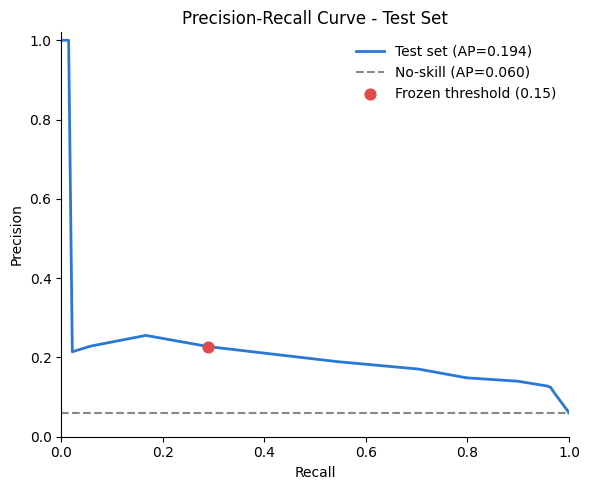

In [16]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve, color=PALETTE["blue"], linewidth=2,
        label=f"Test set (AP={test_metrics['pr_auc']:.3f})")
ax.axhline(no_skill_pr_auc_test, color="#898781", linestyle="--", linewidth=1.5,
           label=f"No-skill (AP={no_skill_pr_auc_test:.3f})")
ax.scatter([test_operating_point["recall"]], [test_operating_point["precision"]],
           color=PALETTE["red"], zorder=5, s=60, label=f"Frozen threshold ({operating_threshold})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Test Set")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_figure(fig, "pr_curve_test.png")
plt.show()

### Log the final test result

Appended to `experiments.csv` (the project's full evidence trail, `eval_split
= "test"`) and written to `results/metrics.json` (the single committed
summary of this project's real-world number).

In [17]:
log_experiment({
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "seed": RANDOM_STATE,
    "model": best_model_config["model_name"],
    "balancing_strategy": best_model_config["balancing_strategy"],
    "params_summary": f"calibration={risk_config['calibration_method']}, threshold={operating_threshold}",
    "eval_split": "test",
    "pr_auc": test_metrics["pr_auc"],
    "recall": test_metrics["recall"],
    "precision": test_metrics["precision"],
    "macro_f1": test_metrics["macro_f1"],
    "mcc": test_metrics["mcc"],
    "roc_auc": test_metrics["roc_auc"],
    "brier_score": test_metrics["brier_score"],
    "cv_pr_auc_mean": best_model_config["cv_pr_auc_mean"],
    "cv_pr_auc_std": best_model_config["cv_pr_auc_std"],
}, EXPERIMENTS_CSV_PATH)

Logged 'XGBoost' (test) -> /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv


## 5. Step 2 — Honest Comparison to Validation

**The test number above is the headline real-world estimate for this
project.** Validation numbers (Notebook 05) were used to make decisions -
which calibration method, which threshold, which tiers; the test numbers were
not and cannot be, since they were only just computed for the first time,
above. Comparing them tells us how much those validation-based decisions
generalize, not which one was "right."

Both rows below are measured **at the same frozen threshold**, so the
comparison is apples-to-apples: validation's PR-AUC is post-calibration
(`pr_auc_after_calibration` from `risk_config.json`), and its recall/precision
are `risk_config.json`'s own `operating_point_metrics` — the exact numbers
Notebook 05 reported at this threshold, not recomputed here.

In [18]:
val_reference = {
    "split": "Validation (Notebook 05, frozen threshold)",
    "pr_auc": risk_config["pr_auc_after_calibration"],
    "recall": risk_config["operating_point_metrics"]["recall"],
    "precision": risk_config["operating_point_metrics"]["precision"],
}
test_reference = {
    "split": "Test (this notebook, same frozen threshold)",
    "pr_auc": test_metrics["pr_auc"],
    "recall": test_metrics["recall"],
    "precision": test_metrics["precision"],
}
comparison_df = pd.DataFrame([val_reference, test_reference])
display(comparison_df.round(4))

pr_auc_gap = val_reference["pr_auc"] - test_reference["pr_auc"]
recall_gap = val_reference["recall"] - test_reference["recall"]
print(f"\nPR-AUC:    validation {val_reference['pr_auc']:.4f} -> test {test_reference['pr_auc']:.4f}  (gap {pr_auc_gap:+.4f})")
print(f"Recall:    validation {val_reference['recall']:.4f} -> test {test_reference['recall']:.4f}  (gap {recall_gap:+.4f})")

,split,pr_auc,recall,precision
0,"Validation (Notebook 05, frozen threshold)",0.2196,0.3525,0.2356
1,"Test (this notebook, same frozen threshold)",0.1945,0.2899,0.2273



PR-AUC:    validation 0.2196 -> test 0.1945  (gap +0.0251)
Recall:    validation 0.3525 -> test 0.2899  (gap +0.0627)


### Tripwire: a test score *higher* than validation needs scrutiny, not celebration

A modest drop from validation to test is normal and expected — validation
numbers already benefited from being the split every earlier decision was
optimized against, even indirectly. A test score that comes in *meaningfully
above* validation is usually a red flag: a different preprocessing path, a
threshold or tier recomputed on test instead of loaded from
`risk_config.json`, or some other quiet inconsistency — not genuinely better
generalization. The check below doesn't just say this; it looks.

In [19]:
LARGE_GAP_WATCH_THRESHOLD = 0.05  # absolute PR-AUC points - illustrative "worth discussing" bar

if pr_auc_gap < -1e-9:
    print(f"TRIPWIRE: test PR-AUC ({test_reference['pr_auc']:.4f}) is ABOVE validation "
          f"({val_reference['pr_auc']:.4f}) by {abs(pr_auc_gap):.4f}. This can happen "
          "legitimately (sampling variance across splits), but it is also the classic "
          "symptom of a subtle inconsistency. Before trusting this number, confirm: "
          "(a) `preprocessing_pipeline` above was loaded via joblib, never fit in this "
          "notebook; (b) `operating_threshold` and the tier boundaries came from "
          "risk_config.json, never recomputed; (c) `calibrated_model` is the object "
          "loaded from calibrated_model.joblib, not a freshly-fit one. All three hold "
          "here by construction - no cell in this notebook calls .fit() on the "
          "pipeline or the model, and no threshold/tier-search code exists in this "
          "notebook at all.")
elif pr_auc_gap > LARGE_GAP_WATCH_THRESHOLD:
    print(f"NOTE: test PR-AUC is {pr_auc_gap:.4f} below validation - larger than the "
          f"{LARGE_GAP_WATCH_THRESHOLD} illustrative 'worth discussing' bar. This is "
          "reported as-is, per this notebook's one rule: a disappointing test result "
          "does not get corrected retroactively. It may reflect validation-set overfitting "
          "in the calibration/threshold choice, or simply a harder test split by chance.")
else:
    print(f"Test PR-AUC is within {LARGE_GAP_WATCH_THRESHOLD} of validation - a modest, "
          "expected difference, not a red flag.")

Test PR-AUC is within 0.05 of validation - a modest, expected difference, not a red flag.


## 6. Step 3 — Temporal Robustness Check (the "stunt double")

**This is a separate, throwaway model, not the project's final model.** Its
only purpose is to answer one question: does this modelling *approach*
(same model family, same hyperparameters, same class-weighting recipe -
loaded from `best_model_config.json`) still work when trained and evaluated
across a genuine time boundary, rather than a random stratified split?

It is retrained **from scratch on 1994-95 data only** (`train_temporal.parquet`)
and evaluated **once on 1996 data only** (`test_temporal.parquet`) - it never
sees 1996 during fitting. It is **not calibrated, not thresholded, and not
saved** as a deployable artifact; its predictions below use the plain 0.5
cutoff purely as an uncalibrated reference point, not a chosen operating
threshold.

**Expected context:** the 1996 fraud rate (~5.2%) differs from the ~6%
overall/stratified rate by construction — Notebook 02 deliberately did not
stratify this split, since the drift *is* the point of the check, not
something to correct for.

In [20]:
train_temporal_df = pd.read_parquet(TRAIN_TEMPORAL_PATH)
test_temporal_df = pd.read_parquet(TEST_TEMPORAL_PATH)

train_temporal_years = set(train_temporal_df["Year"].unique())
test_temporal_years = set(test_temporal_df["Year"].unique())

assert train_temporal_years == {1994, 1995}, f"train_temporal contains unexpected years: {train_temporal_years}"
assert test_temporal_years == {1996}, f"test_temporal contains unexpected years: {test_temporal_years}"
assert set(train_temporal_df.index).isdisjoint(test_temporal_df.index), (
    "train_temporal and test_temporal share row indices - the temporal model would "
    "risk being trained on data it's evaluated on."
)

print(f"train_temporal: {train_temporal_df.shape[0]:,} rows, years {sorted(train_temporal_years)}, "
      f"fraud rate {train_temporal_df[TARGET_COL].mean() * 100:.2f}%")
print(f"test_temporal:  {test_temporal_df.shape[0]:,} rows, year(s) {sorted(test_temporal_years)}, "
      f"fraud rate {test_temporal_df[TARGET_COL].mean() * 100:.2f}%")
print("\nPASSED: no year bleed between train_temporal and test_temporal.")

train_temporal: 11,336 rows, years [np.int64(1994), np.int64(1995)], fraud rate 6.26%
test_temporal:  4,083 rows, year(s) [np.int64(1996)], fraud rate 5.22%

PASSED: no year bleed between train_temporal and test_temporal.


### Fit a fresh preprocessing pipeline on `train_temporal` only

The saved `preprocessing_pipeline.joblib` was fit on the *primary* training
split, which is blind to `Year` and therefore includes some 1996 rows —
reusing it here would let 1996 information leak into this specific check's
premise. A new pipeline, identical in structure to Notebook 02's, is fit
fresh on `train_temporal` only. This does not touch or change the project's
one frozen `preprocessing_pipeline.joblib`.

In [21]:
ORDINAL_FEATURES: dict = {
    "VehiclePrice": ["less than 20000", "20000 to 29000", "30000 to 39000",
                      "40000 to 59000", "60000 to 69000", "more than 69000"],
    "AgeOfVehicle": ["new", "2 years", "3 years", "4 years", "5 years",
                      "6 years", "7 years", "more than 7"],
    "Days_Policy_Accident": ["none", "1 to 7", "8 to 15", "15 to 30", "more than 30"],
    "Days_Policy_Claim": ["none", "8 to 15", "15 to 30", "more than 30"],
    "PastNumberOfClaims": ["none", "1", "2 to 4", "more than 4"],
    "NumberOfSuppliments": ["none", "1 to 2", "3 to 5", "more than 5"],
    "NumberOfCars": ["1 vehicle", "2 vehicles", "3 to 4", "5 to 8", "more than 8"],
    "AddressChange_Claim": ["no change", "under 6 months", "1 year", "2 to 3 years", "4 to 8 years"],
}
NOMINAL_FEATURES = [
    "Make", "BasePolicy", "VehicleCategory", "Fault", "Sex", "MaritalStatus",
    "AccidentArea", "PoliceReportFiled", "WitnessPresent", "AgentType",
    "Month", "DayOfWeek", "MonthClaimed", "DayOfWeekClaimed",
]
NUMERIC_IMPUTE_FEATURES = ["Age"]
PASSTHROUGH_FEATURES = [
    "WeekOfMonth", "WeekOfMonthClaimed", "Deductible", "DriverRating", "Year",
    "Age_was_missing",
]


def build_preprocessing_pipeline(ordinal_features: dict, nominal_features: list,
                                  numeric_impute_features: list, passthrough_features: list) -> ColumnTransformer:
    """Identical shape to Notebook 02's - reproduced here (rather than reusing the
    saved pipeline) specifically so this check can be fit on train_temporal alone."""
    ordinal_cols = list(ordinal_features.keys())
    ordinal_categories = list(ordinal_features.values())
    return ColumnTransformer(
        transformers=[
            ("ordinal", OrdinalEncoder(categories=ordinal_categories,
                                        handle_unknown="use_encoded_value", unknown_value=-1),
             ordinal_cols),
            ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_features),
            ("age_impute", SimpleImputer(strategy="median"), numeric_impute_features),
            ("passthrough", "passthrough", passthrough_features),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


temporal_pipeline = build_preprocessing_pipeline(
    ORDINAL_FEATURES, NOMINAL_FEATURES, NUMERIC_IMPUTE_FEATURES, PASSTHROUGH_FEATURES,
)

X_train_temporal_df = train_temporal_df.drop(columns=[TARGET_COL])
X_test_temporal_df = test_temporal_df.drop(columns=[TARGET_COL])

X_train_temporal = temporal_pipeline.fit_transform(X_train_temporal_df)  # fit on temporal-train ONLY
X_test_temporal = temporal_pipeline.transform(X_test_temporal_df)
y_train_temporal = train_temporal_df[TARGET_COL].to_numpy()
y_test_temporal = test_temporal_df[TARGET_COL].to_numpy()

print(f"X_train_temporal: {X_train_temporal.shape}  |  X_test_temporal: {X_test_temporal.shape}")

X_train_temporal: (11336, 94)  |  X_test_temporal: (4083, 94)


### Rebuild the frozen recipe and retrain from scratch

Only the `class_weight` arm is implemented here, since that is what
`best_model_config.json` actually records as the selected balancing
strategy — reconstructing a SMOTENC pipeline is intentionally out of scope
for a check that exists to test *this project's actual recipe*, not every
recipe that could have been chosen.

In [22]:
if best_model_config["balancing_strategy"] != "class_weight":
    raise NotImplementedError(
        f"best_model_config.json records balancing_strategy="
        f"'{best_model_config['balancing_strategy']}', but this notebook's temporal "
        "check only implements the class_weight recipe. Extend this cell (mirroring "
        "Notebook 04's Experiment.build_estimator SMOTENC branch) before proceeding."
    )

temporal_hyperparameters = best_model_config["hyperparameters"]
n_negative_temporal = int((y_train_temporal == 0).sum())
n_positive_temporal = int((y_train_temporal == 1).sum())
temporal_scale_pos_weight = n_negative_temporal / n_positive_temporal

shared_params = dict(
    n_estimators=temporal_hyperparameters["n_estimators"],
    learning_rate=temporal_hyperparameters["learning_rate"],
    max_depth=temporal_hyperparameters["max_depth"],
    subsample=temporal_hyperparameters["subsample"],
    colsample_bytree=temporal_hyperparameters["colsample_bytree"],
    reg_alpha=temporal_hyperparameters["reg_alpha"],
    reg_lambda=temporal_hyperparameters["reg_lambda"],
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

if best_model_config["model_name"] == "XGBoost":
    temporal_base_estimator = XGBClassifier(
        **shared_params, min_child_weight=temporal_hyperparameters["min_child_weight"],
        objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=temporal_scale_pos_weight,
    )
elif best_model_config["model_name"] == "LightGBM":
    temporal_base_estimator = LGBMClassifier(
        **shared_params, min_child_samples=temporal_hyperparameters["min_child_samples"],
        objective="binary", metric="average_precision", scale_pos_weight=temporal_scale_pos_weight,
        verbosity=-1,
    )
else:
    raise ValueError(f"Unknown model_name in best_model_config.json: {best_model_config['model_name']}")

temporal_model_spec = EarlyStoppingGBDT(
    temporal_base_estimator, early_stopping_rounds=best_model_config["early_stopping_rounds"],
    random_state=RANDOM_STATE,
)

temporal_result = fit_and_evaluate(
    temporal_model_spec, X_train_temporal, y_train_temporal, X_test_temporal, y_test_temporal,
)
temporal_metrics = temporal_result["metrics"]

print(f"Temporal check (train 1994-95 -> test 1996), {best_model_config['model_name']} + class_weight, "
      f"scale_pos_weight={temporal_scale_pos_weight:.2f}:")
print(f"  PR-AUC:    {temporal_metrics['pr_auc']:.4f}")
print(f"  Recall:    {temporal_metrics['recall']:.4f}  (at default 0.5 - uncalibrated, illustrative only)")
print(f"  Precision: {temporal_metrics['precision']:.4f}")

Temporal check (train 1994-95 -> test 1996), XGBoost + class_weight, scale_pos_weight=14.97:
  PR-AUC:    0.1157
  Recall:    0.2160  (at default 0.5 - uncalibrated, illustrative only)
  Precision: 0.0671


### Log the temporal check

In [23]:
log_experiment({
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "seed": RANDOM_STATE,
    "model": best_model_config["model_name"],
    "balancing_strategy": "class_weight",
    "params_summary": "temporal robustness check - same recipe as best_model_config.json, retrained on 1994-95 only",
    "eval_split": "test_temporal",
    "pr_auc": temporal_metrics["pr_auc"],
    "recall": temporal_metrics["recall"],
    "precision": temporal_metrics["precision"],
    "macro_f1": temporal_metrics["macro_f1"],
    "mcc": temporal_metrics["mcc"],
    "roc_auc": temporal_metrics["roc_auc"],
    "brier_score": temporal_metrics["brier_score"],
    "cv_pr_auc_mean": np.nan,
    "cv_pr_auc_std": np.nan,
}, EXPERIMENTS_CSV_PATH)

Logged 'XGBoost' (test_temporal) -> /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv


> **This temporal model is discarded after this cell.** It is not saved, not
> calibrated, not deployed, and does not replace or update anything from
> Notebooks 04-05. Its entire contribution to the project is the three
> numbers printed above and one sentence in the summary below.

## 7. Save `results/metrics.json`

The single committed summary of this project's real-world numbers: the test
result (headline), the validation-vs-test comparison, and the temporal
robustness check.

In [24]:
final_metrics = {
    "test": {
        "n_claims": int(len(test_df)),
        "fraud_rate_pct": round(float(y_test.mean()) * 100, 2),
        "no_skill_pr_auc": to_jsonable(no_skill_pr_auc_test),
        "metrics": {k: to_jsonable(v) for k, v in test_metrics.items()},
        "operating_threshold": operating_threshold,
        "operating_point": {k: to_jsonable(v) for k, v in test_operating_point.items()},
        "risk_tiers": test_tier_summary_df.to_dict(orient="records"),
        "calibration_method": risk_config["calibration_method"],
    },
    "validation_vs_test": {
        "validation": {k: to_jsonable(v) for k, v in val_reference.items()},
        "test": {k: to_jsonable(v) for k, v in test_reference.items()},
        "pr_auc_gap": to_jsonable(pr_auc_gap),
        "recall_gap": to_jsonable(recall_gap),
    },
    "temporal_robustness_check": {
        "description": "Same model recipe as best_model_config.json, retrained from "
                        "scratch on 1994-95 only, evaluated once on 1996 only. Not "
                        "calibrated, not thresholded, not the project's final model.",
        "train_years": sorted(int(y) for y in train_temporal_years),
        "test_year": sorted(int(y) for y in test_temporal_years),
        "train_fraud_rate_pct": round(float(y_train_temporal.mean()) * 100, 2),
        "test_fraud_rate_pct": round(float(y_test_temporal.mean()) * 100, 2),
        "metrics": {k: to_jsonable(v) for k, v in temporal_metrics.items()},
    },
    "source_model": {
        "model_name": best_model_config["model_name"],
        "balancing_strategy": best_model_config["balancing_strategy"],
        "optuna_trial_number": best_model_config["optuna"]["trial_number"],
    },
    "seed": RANDOM_STATE,
    "generated_at": datetime.now(timezone.utc).isoformat(),
}

with open(METRICS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2)
saved_files.append(METRICS_JSON_PATH)
print(f"Saved -> {METRICS_JSON_PATH}")
display(Markdown(f"```json\n{json.dumps(final_metrics, indent=2)}\n```"))

Saved -> /content/drive/MyDrive/InsuranceFraudProject/results/metrics.json


```json
{
  "test": {
    "n_claims": 2313,
    "fraud_rate_pct": 5.97,
    "no_skill_pr_auc": 0.05966277561608301,
    "metrics": {
      "pr_auc": 0.19448545374214238,
      "recall": 0.2898550724637681,
      "precision": 0.22727272727272727,
      "macro_f1": 0.6002549543268378,
      "mcc": 0.20307680991916524,
      "roc_auc": 0.8296968182575379,
      "brier_score": 0.05147200156748197
    },
    "operating_threshold": 0.15,
    "operating_point": {
      "threshold": 0.15,
      "recall": 0.2898550724637681,
      "precision": 0.22727272727272727,
      "fpr": 0.0625287356321839,
      "caseload_pct": 7.609165585819282,
      "tp": 40,
      "fp": 136,
      "fn": 98,
      "tn": 2039
    },
    "risk_tiers": [
      {
        "tier": "Low",
        "n_claims": 1573,
        "caseload_pct": 68.01,
        "n_fraud": 28,
        "fraud_rate_pct": 1.78,
        "recall_share_pct": 20.29
      },
      {
        "tier": "Medium",
        "n_claims": 564,
        "caseload_pct": 24.38,
        "n_fraud": 70,
        "fraud_rate_pct": 12.41,
        "recall_share_pct": 50.72
      },
      {
        "tier": "High",
        "n_claims": 176,
        "caseload_pct": 7.61,
        "n_fraud": 40,
        "fraud_rate_pct": 22.73,
        "recall_share_pct": 28.99
      }
    ],
    "calibration_method": "isotonic"
  },
  "validation_vs_test": {
    "validation": {
      "split": "Validation (Notebook 05, frozen threshold)",
      "pr_auc": 0.21962625025079313,
      "recall": 0.35251798561151076,
      "precision": 0.23557692307692307
    },
    "test": {
      "split": "Test (this notebook, same frozen threshold)",
      "pr_auc": 0.19448545374214238,
      "recall": 0.2898550724637681,
      "precision": 0.22727272727272727
    },
    "pr_auc_gap": 0.025140796508650753,
    "recall_gap": 0.06266291314774264
  },
  "temporal_robustness_check": {
    "description": "Same model recipe as best_model_config.json, retrained from scratch on 1994-95 only, evaluated once on 1996 only. Not calibrated, not thresholded, not the project's final model.",
    "train_years": [
      1994,
      1995
    ],
    "test_year": [
      1996
    ],
    "train_fraud_rate_pct": 6.26,
    "test_fraud_rate_pct": 5.22,
    "metrics": {
      "pr_auc": 0.11568024575326208,
      "recall": 0.215962441314554,
      "precision": 0.06705539358600583,
      "macro_f1": 0.4956429884863585,
      "mcc": 0.030087142257238044,
      "roc_auc": 0.7342820055561621,
      "brier_score": 0.11441588654154275
    }
  },
  "source_model": {
    "model_name": "XGBoost",
    "balancing_strategy": "class_weight",
    "optuna_trial_number": 58
  },
  "seed": 42,
  "generated_at": "2026-08-29T12:19:48.784810+00:00"
}
```

## 8. Sanity Checks

Each check targets a specific way this notebook could go wrong.

### The frozen pipeline and model were not fit or mutated in this notebook

In [25]:
X_test_recheck = preprocessing_pipeline.transform(X_test_df)
assert np.array_equal(X_test, X_test_recheck), (
    "Transforming X_test_df twice gave different results - the preprocessing "
    "pipeline's fitted state may have changed between calls."
)

y_proba_test_recheck = calibrated_model.predict_proba(X_test)[:, 1]
assert np.array_equal(y_proba_test, y_proba_test_recheck), (
    "Scoring X_test twice gave different probabilities - the calibrated model's "
    "fitted state may have changed between calls."
)
print("PASSED: both the preprocessing pipeline and the calibrated model produced "
      "identical output across repeated calls - neither was mutated in this notebook.")

PASSED: both the preprocessing pipeline and the calibrated model produced identical output across repeated calls - neither was mutated in this notebook.


### The frozen threshold and tier boundaries were used exactly as saved

In [26]:
with open(RISK_CONFIG_PATH, "r", encoding="utf-8") as f:
    risk_config_recheck = json.load(f)

assert operating_threshold == risk_config_recheck["operating_threshold"], (
    "operating_threshold in memory does not match risk_config.json on disk."
)
assert LOW_RISK_MAX == risk_config_recheck["risk_tiers"]["low_max"], "low_max drifted from risk_config.json."
assert HIGH_RISK_MIN == risk_config_recheck["risk_tiers"]["high_min"], "high_min drifted from risk_config.json."
print(f"PASSED: threshold ({operating_threshold}) and tier boundaries "
      f"({LOW_RISK_MAX}, {HIGH_RISK_MIN}) match risk_config.json on disk exactly - "
      "this notebook contains no threshold- or tier-selection code of its own.")

PASSED: threshold (0.15) and tier boundaries (0.075, 0.15) match risk_config.json on disk exactly - this notebook contains no threshold- or tier-selection code of its own.


### The temporal model never saw 1996 during training

In [27]:
assert train_temporal_years == {1994, 1995}, "train_temporal_years drifted."
assert test_temporal_years == {1996}, "test_temporal_years drifted."
assert set(train_temporal_df.index).isdisjoint(test_temporal_df.index), (
    "train_temporal and test_temporal share row indices."
)
print("PASSED: temporal model trained only on 1994-95, evaluated only on 1996, no "
      "row-index overlap between the two.")

PASSED: temporal model trained only on 1994-95, evaluated only on 1996, no row-index overlap between the two.


### Nothing in this notebook altered an earlier decision

In [28]:
with open(BEST_MODEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    best_model_config_recheck = json.load(f)

assert best_model_config_recheck == best_model_config, (
    "best_model_config.json changed during this notebook's run - it must remain frozen."
)
with open(RISK_CONFIG_PATH, "r", encoding="utf-8") as f:
    risk_config_final_check = json.load(f)
assert risk_config_final_check == risk_config, (
    "risk_config.json changed during this notebook's run - it must remain frozen."
)
print("PASSED: best_model_config.json and risk_config.json are unchanged on disk - "
      "this notebook only ever wrote to metrics.json and experiments.csv, never to "
      "the frozen model/calibration/threshold artifacts.")

PASSED: best_model_config.json and risk_config.json are unchanged on disk - this notebook only ever wrote to metrics.json and experiments.csv, never to the frozen model/calibration/threshold artifacts.


All sanity checks passed. If any of these fail on a re-run, treat it as a
hard stop: something in this notebook touched an artifact it should only
have read.

## Final Test Evaluation Summary

In [29]:
gap_note = (
    f"a {pr_auc_gap:.4f} drop from validation, within the {LARGE_GAP_WATCH_THRESHOLD} watch threshold"
    if 0 <= pr_auc_gap <= LARGE_GAP_WATCH_THRESHOLD else
    f"a {pr_auc_gap:.4f} drop from validation - beyond the {LARGE_GAP_WATCH_THRESHOLD} watch threshold, reported as-is"
    if pr_auc_gap > LARGE_GAP_WATCH_THRESHOLD else
    f"{abs(pr_auc_gap):.4f} ABOVE validation - see the tripwire check in Step 2 before trusting this"
)

summary_md = f"""
**Headline result (test set, n={len(test_df):,}, fraud rate {y_test.mean() * 100:.2f}%):**
PR-AUC **{test_metrics['pr_auc']:.4f}** (no-skill {no_skill_pr_auc_test:.4f}), Recall
{test_metrics['recall']:.4f}, Precision {test_metrics['precision']:.4f}, Macro-F1
{test_metrics['macro_f1']:.4f}, MCC {test_metrics['mcc']:.4f}, ROC-AUC
{test_metrics['roc_auc']:.4f}, Brier {test_metrics['brier_score']:.4f} - at the frozen
threshold {operating_threshold}, flagging {test_operating_point['caseload_pct']:.1f}% of
test claims.

**Validation vs. test:** {gap_note}. The test number above, not the validation number,
is this project's real-world estimate.

**Temporal robustness check:** the same recipe ({best_model_config['model_name']} +
class_weight), retrained from scratch on 1994-95 and evaluated once on 1996, scored
PR-AUC {temporal_metrics['pr_auc']:.4f} (recall {temporal_metrics['recall']:.4f},
precision {temporal_metrics['precision']:.4f}, uncalibrated 0.5 cutoff). This is a
robustness signal only - not a second candidate, not calibrated, not deployed, and not
a claim about how fraud has evolved since 1996 (see Notebook 01's historical-benchmark
framing).

**Nothing was tuned here.** No threshold was adjusted, no model re-selected, no
calibration re-fit, based on any number in this notebook - the frozen artifacts from
Notebooks 04-05 are unchanged on disk (verified above), and this is the only notebook
that opened `test.parquet`, exactly once.

**All sanity checks passed:** pipeline and model produced identical output across
repeated calls, threshold/tier boundaries matched risk_config.json exactly, the
temporal model saw no 1996 data during training, and the frozen config files are
byte-identical to how this notebook found them.

**Saved to Drive:** `results/metrics.json`, updated `experiments.csv`, and four
figures (PR curve, confusion matrix, reliability curve, risk-tier chart) in
`results/figures/test/`.

**What comes next:** Notebook 07's SHAP analysis explains *why* this frozen model
makes the predictions it does - it does not change the model, calibration, threshold,
or any number reported here.
"""
display(Markdown(summary_md))


**Headline result (test set, n=2,313, fraud rate 5.97%):**
PR-AUC **0.1945** (no-skill 0.0597), Recall
0.2899, Precision 0.2273, Macro-F1
0.6003, MCC 0.2031, ROC-AUC
0.8297, Brier 0.0515 - at the frozen
threshold 0.15, flagging 7.6% of
test claims.

**Validation vs. test:** a 0.0251 drop from validation, within the 0.05 watch threshold. The test number above, not the validation number,
is this project's real-world estimate.

**Temporal robustness check:** the same recipe (XGBoost +
class_weight), retrained from scratch on 1994-95 and evaluated once on 1996, scored
PR-AUC 0.1157 (recall 0.2160,
precision 0.0671, uncalibrated 0.5 cutoff). This is a
robustness signal only - not a second candidate, not calibrated, not deployed, and not
a claim about how fraud has evolved since 1996 (see Notebook 01's historical-benchmark
framing).

**Nothing was tuned here.** No threshold was adjusted, no model re-selected, no
calibration re-fit, based on any number in this notebook - the frozen artifacts from
Notebooks 04-05 are unchanged on disk (verified above), and this is the only notebook
that opened `test.parquet`, exactly once.

**All sanity checks passed:** pipeline and model produced identical output across
repeated calls, threshold/tier boundaries matched risk_config.json exactly, the
temporal model saw no 1996 data during training, and the frozen config files are
byte-identical to how this notebook found them.

**Saved to Drive:** `results/metrics.json`, updated `experiments.csv`, and four
figures (PR curve, confusion matrix, reliability curve, risk-tier chart) in
`results/figures/test/`.

**What comes next:** Notebook 07's SHAP analysis explains *why* this frozen model
makes the predictions it does - it does not change the model, calibration, threshold,
or any number reported here.


### Files saved by this notebook

In [30]:
print("Final evaluation outputs written this run:")
for p in saved_files:
    print(f"  - {p}")

Final evaluation outputs written this run:
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/confusion_matrix_test.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/risk_tiers_test.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/reliability_curve_test.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/test/pr_curve_test.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/metrics.json
